# 01_collection_phase1_v5 — DART 사업보고서 표/본문 분리 + 정정공시 fallback

> **작성자**: 이동원 · **작성일**: 2026-05-16 · **버전**: v5
> **이전 버전**: `01_collection_phase1_v4.ipynb` (viewer 4/5 통과, 단 VI 섹션 81%가 표라 표/본문 분리 보존 필요)
> **벤치마킹**: [dart-fss-text](https://github.com/jaepil-choi/dart-fss-text) + 본 프로젝트 ESG 가설 요구사항
> **보고서**: `members/이동원/reports/01_collection/01_collection_phase1_v5_보고서.md`

## v4 → v5 핵심 변경

| 영역 | v4 | v5 |
|---|---|---|
| 텍스트 추출 | 평탄화 (표+본문 한 덩어리) | **3가지 모두 저장**: `section_text` (전체) + **`section_body` (본문)** + **`section_tables` (표)** |
| 정정공시 처리 | (2024.12) 사업보고서만 — 없으면 FAIL_LIST | **차순위 fallback**: 사업보고서 → 반기 → 분기 → 정정신고서 + status 명시 |
| VI 섹션 G passage 안정성 | 위험 (표 평탄화 시 수치 노이즈) | 본문/표 분리로 02_preprocessing에서 선택 가능 |

## v5에서 풀어야 할 4가지 영역

1. ✅ **영역 1 — 표 안 데이터 추출 정확성** (v4에서 검증 완료)
2. 🚨 **영역 2 — 표/본문 분리** (Fix #12) — VI 81% 표 발견으로 필요성 증명
3. ⚠️ **영역 3 — 정정공시·에러 fallback** (Fix #13) — (2024.06) 분기·정정신고서 변종 대응
4. ⏳ **영역 4 — 회사·연도 다양성** (Phase 2A 50건 batch에서)

## 가이드 line 매핑 (v4와 동일 + 강화)

| 가이드 line | v4 | v5 |
|---|---|---|
| line 18 (II/IV/VI target) | SECTION-1 추출 | 동일 + body/tables 분리 |
| line 69 (정정공시 기록) | last_reprt_at=Y | **차순위 fallback 추가** |
| line 156 (XML→텍스트) | itertext 평탄화 | 본문/표 두 corpus 분리 |
| line 157 (II/IV/VI 발췌) | SECTION-1 노드 순회 | 동일 |
| line 158 (ESG passage) | seed 매칭 | 동일 (단 02에서 body/tables 선택 가능) |
| line 170-172 (실패 행 이유) | status 세분화 | **WARN_FALLBACK_*** 추가 |


---

## Step 0 · 가이드 매핑·위반금지 8항목 사전 점검 (v4와 동일)

가이드 line 18·35·67·69·94·137-146·153-172·216-222·286 모두 v5에서도 동일하게 준수.
v5는 추가로:
- **표/본문 분리 보존** → 위반금지 #1 (실패 가짜 0 ❌)을 더 강화 (G 차원 passage 누락 방지)
- **정정공시 fallback** → 위반금지 #1 + 가이드 line 69 (정정공시 rcept_no 기록) 강화


---

## Step 1 · 환경 셋업 + API key 안전 (v4와 동일)


In [1]:
# Colab 사용자만 주석 해제
# !pip install python-dotenv pandas requests lxml tqdm matplotlib pyarrow rapidfuzz

import os, sys, re, json, time, zipfile, warnings
from io import BytesIO
from copy import deepcopy
from pathlib import Path
from datetime import datetime

import requests
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from dotenv import load_dotenv
from lxml import etree

try:
    from rapidfuzz import fuzz
    RAPIDFUZZ_AVAILABLE = True
except ImportError:
    RAPIDFUZZ_AVAILABLE = False

import matplotlib
matplotlib.rcParams['axes.unicode_minus'] = False
for f in ['Malgun Gothic', 'AppleGothic', 'NanumGothic', 'DejaVu Sans']:
    try:
        matplotlib.rcParams['font.family'] = f; break
    except Exception:
        pass
warnings.filterwarnings('ignore')


def find_project_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / 'data' / 'company_master.csv').exists():
            return candidate
    raise FileNotFoundError("project root not found")


def mask_key(key: str) -> str:
    return f"{key[:4]}...len={len(key)}" if key else '(empty)'


ROOT = find_project_root()
print(f"📍 ROOT: {ROOT}")
load_dotenv(ROOT / '.env')

# v1·v2 학습 — KEY_CANDIDATES 후보 리스트 (이동원 .env = API_KEY)
KEY_CANDIDATES = ['OPENDART_API_KEY', 'API_KEY', 'DART_API_KEY']
API_KEY = next((os.getenv(k) for k in KEY_CANDIDATES if os.getenv(k)), None)
assert API_KEY, f"❌ {KEY_CANDIDATES} 중 어느 것도 .env에 없습니다."
print(f"✅ API key 로드 ({mask_key(API_KEY)})")

DIR_RAW = ROOT / 'data' / 'raw'
DIR_INTERIM = ROOT / 'data' / 'interim'
DIR_CACHE = ROOT / 'data' / 'cache'
DIR_LOGS = ROOT / 'logs'
for d in [DIR_RAW, DIR_INTERIM, DIR_CACHE, DIR_LOGS]:
    d.mkdir(parents=True, exist_ok=True)
print(f"📁 디렉토리 OK · lxml=True · rapidfuzz={RAPIDFUZZ_AVAILABLE}")


📍 ROOT: c:\Users\kik32\workspace\unstructured-data-processing-final-project
✅ API key 로드 (0e1e...len=40)
📁 디렉토리 OK · lxml=True · rapidfuzz=True


---

## Step 1+ · section_code 사전 (v4와 동일)


In [2]:
SECTION_CODE_MAP = {
    'CEO_CERT':    ('TTL_CEO_CERT', '대표이사 등의 확인'),
    'I':   ('010000', 'I. 회사의 개요'),
    'II':  ('020000', 'II. 사업의 내용'),
    'III': ('030000', 'III. 재무에 관한 사항'),
    'IV':  ('040000', 'IV. 이사의 경영진단 및 분석의견'),
    'V':   ('050000', 'V. 회계감사인의 감사의견 등'),
    'VI':  ('060000', 'VI. 이사회 등 회사의 기관에 관한 사항'),
    'VII': ('070000', 'VII. 주주에 관한 사항'),
    'VIII':('080000', 'VIII. 임원 및 직원 등에 관한 사항'),
    'IX':  ('090000', 'IX. 계열회사 등에 관한 사항'),
    'X':   ('100000', 'X. 대주주 등과의 거래내용'),
    'XI':  ('110000', 'XI. 그 밖에 투자자 보호를 위하여 필요한 사항'),
    'XII': ('TTL_APPENDIX', 'XII. 상세표'),
    'EXPERT_CERT': ('', '전문가의 확인'),
}
ESG_TARGET_LABELS = ['II', 'IV', 'VI']

TITLE_PATTERNS = {
    'I':   [r'^I\.\s', r'^Ⅰ\.\s', r'회사의\s*개요'],
    'II':  [r'^II\.\s', r'^Ⅱ\.\s', r'^2\.\s', r'사업의\s*내용'],
    'III': [r'^III\.\s', r'^Ⅲ\.\s', r'^3\.\s', r'재무에\s*관한\s*사항'],
    'IV':  [r'^IV\.\s', r'^Ⅳ\.\s', r'^4\.\s', r'이사의\s*경영진단', r'이사.*경영진단'],
    'V':   [r'^V\.\s', r'^Ⅴ\.\s', r'^5\.\s', r'감사인의\s*감사의견', r'회계감사인'],
    'VI':  [r'^VI\.\s', r'^Ⅵ\.\s', r'^6\.\s', r'이사회\s*등.*기관', r'이사회.*회사의\s*기관'],
    'VII': [r'^VII\.\s', r'^Ⅶ\.\s', r'^7\.\s', r'주주에\s*관한\s*사항'],
    'VIII':[r'^VIII\.\s', r'^Ⅷ\.\s', r'^8\.\s', r'임원\s*및\s*직원'],
    'IX':  [r'^IX\.\s', r'^Ⅸ\.\s', r'^9\.\s', r'계열회사'],
    'X':   [r'^X\.\s', r'^Ⅹ\.\s', r'^10\.\s', r'대주주.*거래내용'],
    'XI':  [r'^XI\.\s', r'^Ⅺ\.\s', r'^11\.\s', r'그\s*밖.*투자자\s*보호'],
}


def parse_aassocnote(aassoc: str) -> tuple:
    if not aassoc or not aassoc.startswith('D-'):
        return (None, None)
    parts = aassoc.split('-')
    if len(parts) < 5:
        return (None, None)
    try:
        x, y, z = int(parts[2]), int(parts[3]), int(parts[4])
        roman = ['', 'I', 'II', 'III', 'IV', 'V', 'VI', 'VII', 'VIII', 'IX', 'X', 'XI', 'XII'][x] if x < 13 else None
        if roman is None:
            return (None, None)
        return (roman, f'{x:02d}{y:02d}{z:02d}')
    except (ValueError, IndexError):
        return (None, None)


def match_title_to_label(title_text: str) -> str:
    if not title_text:
        return None
    text = title_text.strip()
    for label, patterns in TITLE_PATTERNS.items():
        for pat in patterns:
            if re.search(pat, text):
                return label
    return None


---

## Step 2 · 파일럿 대상 (v4와 동일)


In [3]:
PILOT_STOCK = '005930'
PILOT_FISCAL = 2024
PILOT_ESG_YEAR = PILOT_FISCAL + 1

cm = pd.read_csv(ROOT / 'data' / 'company_master.csv', dtype={'stock_code': str})
print(f"📊 company_master: {len(cm)}행 / {cm['stock_code'].nunique()} unique stock")
pilot_row = cm[(cm['stock_code']==PILOT_STOCK) & (cm['fiscal_year']==PILOT_FISCAL)].iloc[0]
print(f"🎯 파일럿: {PILOT_STOCK} × {PILOT_FISCAL} (esg={PILOT_ESG_YEAR})")
pilot_row.to_frame()


📊 company_master: 381행 / 127 unique stock
🎯 파일럿: 005930 × 2024 (esg=2025)


,2
company_name,삼성전자
corp_code,NaN
stock_code,005930
industry,전기전자
fiscal_year,2024
report_code,11011
rcept_no,NaN
esg_source,한국ESG기준원
esg_grade,A
e_grade,B+


---

## Step 3 · stock → corp (v4와 동일)


In [4]:
def fetch_corp_code_map(api_key, cache_dir):
    cache = cache_dir / 'corp_code_map.parquet'
    if cache.exists():
        df = pd.read_parquet(cache)
        print(f"📦 캐시 hit ({len(df):,}건)")
        return df
    res = requests.get("https://opendart.fss.or.kr/api/corpCode.xml",
                       params={'crtfc_key': api_key}, timeout=30)
    res.raise_for_status()
    with zipfile.ZipFile(BytesIO(res.content)) as zf:
        xml_bytes = zf.read(zf.namelist()[0])
    root = etree.fromstring(xml_bytes)
    rows = [{'corp_code':(el.findtext('corp_code') or '').strip(),
             'corp_name':(el.findtext('corp_name') or '').strip(),
             'stock_code':(el.findtext('stock_code') or '').strip()} for el in root.findall('list')]
    df = pd.DataFrame(rows)
    df = df[df['stock_code'].str.len()==6]
    df.to_parquet(cache, index=False)
    return df


corp_map = fetch_corp_code_map(API_KEY, DIR_CACHE)
PILOT_CORP = corp_map[corp_map['stock_code']==PILOT_STOCK].iloc[0]['corp_code']
print(f"✅ {PILOT_STOCK} → {PILOT_CORP}")


📦 캐시 hit (3,965건)
✅ 005930 → 00126380


---

## Step 4 · 🔥 **v5 핵심** · rcept_no 조회 + **정정공시 fallback** (Fix #13 신규)

**v4 → v5 차이:**
- v4: 사업보고서 (2024.12)만 시도 → 없으면 `FAIL_LIST`
- v5: **차순위 fallback** — 사업보고서 → 반기보고서 → 분기보고서 → 정정신고서 → 최후 raise
- 각 fallback 시 `status='WARN_FALLBACK_QUARTERLY'` 등 명시 (위반금지 #1: 가짜 0 ❌)

**탐색 우선순위 (가이드 line 154 + line 69 의도):**
| 우선순위 | 보고서 종류 | report_nm 패턴 | pblntf_detail_ty |
|---|---|---|---|
| 1 (primary) | 사업보고서 (2024.12) | "사업보고서" + "(2024.12)" | A001 |
| 2 (fallback 1) | 반기보고서 (2024.06) | "반기보고서" + "(2024.06)" | A002 |
| 3 (fallback 2) | 분기보고서 (2024.09) | "분기보고서" + "(2024.09)" | A003 |
| 4 (fallback 3) | 정정신고서 — 사업보고서 | "정정" + "사업보고서" + "(2024.12)" | (분기 없음) |
| 5 | 모두 없음 | — | → FAIL_LIST_NO_REPORT |


In [5]:
REPORT_FALLBACK_ORDER = [
    # (label, pblntf_detail_ty, name_keyword, year_offset_within_nm)
    ('PRIMARY_BIZ', 'A001', '사업보고서', '12'),
    ('FALLBACK_HALF', 'A002', '반기보고서', '06'),
    ('FALLBACK_Q3', 'A003', '분기보고서', '09'),
    ('FALLBACK_Q1', 'A003', '분기보고서', '03'),
]


def find_rcept_no_v5(api_key, corp_code, fiscal_year):
    """Fix #13 — 정정공시 fallback. 차순위 시도 + correction 이력 수집."""
    fallback_used = None
    selected = None
    all_candidates = []

    for label, pblntf, kw, mm in REPORT_FALLBACK_ORDER:
        params = {
            'crtfc_key': api_key, 'corp_code': corp_code,
            'bgn_de': f'{fiscal_year+1}0101', 'end_de': f'{fiscal_year+1}1231',
            'pblntf_detail_ty': pblntf, 'last_reprt_at': 'Y', 'page_count': '100',
        }
        res = requests.get('https://opendart.fss.or.kr/api/list.json', params=params, timeout=20)
        res.raise_for_status()
        rows = res.json().get('list', [])
        target_label = f'({fiscal_year}.{mm})'
        finals = [r for r in rows if kw in r.get('report_nm','') and target_label in r.get('report_nm','')]
        if finals:
            sel = finals[0]
            selected = {
                'rcept_no': sel['rcept_no'], 'rcept_dt': sel['rcept_dt'],
                'report_nm': sel['report_nm'], 'fallback_used': label,
                'viewer_url': f"https://dart.fss.or.kr/dsaf001/main.do?rcpNo={sel['rcept_no']}",
            }
            fallback_used = label

            # 정정공시 이력 (last_reprt_at=N으로 모든 후보)
            params_all = {**params, 'last_reprt_at': 'N'}
            res2 = requests.get('https://opendart.fss.or.kr/api/list.json', params=params_all, timeout=20)
            if res2.status_code == 200:
                for r in res2.json().get('list', []):
                    if kw in r.get('report_nm','') and target_label in r.get('report_nm',''):
                        all_candidates.append({
                            'rcept_no': r['rcept_no'], 'rcept_dt': r['rcept_dt'],
                            'report_nm': r['report_nm'], 'fallback_used': label,
                        })
            break

    if selected is None:
        # 최후 시도 — 정정신고서까지 검색
        # (구현 단순화: 본 노트북에서는 1·2·3 fallback만 시도. Phase 2A에서 정정신고서 발견 시 추가)
        raise RuntimeError(f"FAIL_LIST_NO_REPORT — 사업보고서·반기·분기 모두 없음 (corp={corp_code}, fiscal={fiscal_year})")

    return {'selected': selected, 'all_candidates': all_candidates, 'fallback_used': fallback_used}


result_step4 = find_rcept_no_v5(API_KEY, PILOT_CORP, PILOT_FISCAL)
PILOT_RCEPT = result_step4['selected']['rcept_no']
VIEWER_URL = result_step4['selected']['viewer_url']
FALLBACK = result_step4['fallback_used']

print(f"✅ rcept_no={PILOT_RCEPT}")
print(f"   fallback_used: {FALLBACK} ({'정상 사업보고서' if FALLBACK=='PRIMARY_BIZ' else '⚠️ 차순위 fallback'})")
print(f"   viewer: {VIEWER_URL}")
print(f"   정정공시 후보 수: {len(result_step4['all_candidates'])}")


✅ rcept_no=20250311001085
   fallback_used: PRIMARY_BIZ (정상 사업보고서)
   viewer: https://dart.fss.or.kr/dsaf001/main.do?rcpNo=20250311001085
   정정공시 후보 수: 1


---

## Step 5 · document.xml + DOCUMENT-NAME type 판별 (v4 Fix #0 유지)


In [6]:
DOC_TYPE_PATTERN = re.compile(r'<DOCUMENT-NAME[^>]*>([^<]+)</DOCUMENT-NAME>', re.UNICODE)


def download_document_xml_v5(api_key, rcept_no, stock, year, raw_dir, fallback_label='PRIMARY_BIZ'):
    """v4 동일 + fallback_label 기록."""
    zip_path = raw_dir / f'{stock}_{year}_disclosure.zip'
    if zip_path.exists() and zip_path.stat().st_size > 1024:
        zip_bytes = zip_path.read_bytes()
        print(f"📦 캐시 hit: {zip_path.name} ({zip_path.stat().st_size/1024:.1f} KB)")
    else:
        res = requests.get('https://opendart.fss.or.kr/api/document.xml',
                           params={'crtfc_key': api_key, 'rcept_no': rcept_no}, timeout=60)
        res.raise_for_status()
        zip_bytes = res.content
        zip_path.write_bytes(zip_bytes)
        print(f"📥 다운로드: {zip_path.name} ({len(zip_bytes)/1024:.1f} KB)")

    sources = {'사업보고서':[], '반기보고서':[], '분기보고서':[], '연결감사보고서':[], '감사보고서':[], 'unknown':[]}
    with zipfile.ZipFile(BytesIO(zip_bytes)) as zf:
        for name in zf.namelist():
            xml = zf.read(name).decode('utf-8', errors='ignore')
            m = DOC_TYPE_PATTERN.search(xml)
            dt = m.group(1).strip() if m else 'unknown'
            key = dt if dt in sources else 'unknown'
            sources[key].append((name, xml, dt))
            print(f"   - {name}: {len(xml):>10,}자 | DOCUMENT-NAME: {dt}")

    # primary 선택 — fallback에 따라 변경
    if fallback_label == 'PRIMARY_BIZ' and sources['사업보고서']:
        primary = max(sources['사업보고서'], key=lambda x: len(x[1]))
    elif fallback_label == 'FALLBACK_HALF' and sources['반기보고서']:
        primary = max(sources['반기보고서'], key=lambda x: len(x[1]))
    elif fallback_label.startswith('FALLBACK_Q') and sources['분기보고서']:
        primary = max(sources['분기보고서'], key=lambda x: len(x[1]))
    elif sources['unknown']:
        primary = max(sources['unknown'], key=lambda x: len(x[1]))
        print(f"\n⚠️ '{fallback_label}' DOCUMENT-NAME 없음 — unknown fallback")
    else:
        raise RuntimeError(f"FAIL_NO_BUSINESS_REPORT — fallback={fallback_label}")
    print(f"\n⭐ primary: {primary[0]} ({len(primary[1]):,}자)")
    return {'zip_path': zip_path, 'sources': sources, 'primary': primary, 'n_xml_files': len(zf.namelist())}


result_step5 = download_document_xml_v5(API_KEY, PILOT_RCEPT, PILOT_STOCK, PILOT_FISCAL, DIR_RAW, FALLBACK)
PRIMARY_NAME, PRIMARY_XML, PRIMARY_TYPE = result_step5['primary']


📦 캐시 hit: 005930_2024_disclosure.zip (660.2 KB)
   - 20250311001085_00761.xml:    623,804자 | DOCUMENT-NAME: 연결감사보고서
   - 20250311001085_00760.xml:    531,069자 | DOCUMENT-NAME: 감사보고서
   - 20250311001085.xml:  5,780,877자 | DOCUMENT-NAME: 사업보고서

⭐ primary: 20250311001085.xml (5,780,877자)


---

## Step 5+ · 보조 보고서 저장 (v4와 동일, 세분화 축 A)


In [7]:
def save_aux_sources(sources, stock, year, interim_dir):
    name_map = {'연결감사보고서':'aux_audit_consolidated', '감사보고서':'aux_audit_separate'}
    saved = {}
    for dt, suffix in name_map.items():
        items = sources.get(dt, [])
        if not items:
            continue
        out = {'doc_type':dt, 'stock_code':stock, 'fiscal_year':year,
               'files':[{'filename':fn,'doc_name_in_xml':d,'xml_text_length':len(xt),'xml_text':xt}
                        for fn,xt,d in items]}
        path = interim_dir / f'{stock}_{year}_{suffix}.json'
        path.write_text(json.dumps(out, ensure_ascii=False), encoding='utf-8')
        saved[dt] = path
        print(f"💾 [{dt}] {path.name} ({path.stat().st_size/1024:.1f} KB)")
    return saved


aux_saved = save_aux_sources(result_step5['sources'], PILOT_STOCK, PILOT_FISCAL, DIR_INTERIM)


💾 [연결감사보고서] 005930_2024_aux_audit_consolidated.json (763.7 KB)
💾 [감사보고서] 005930_2024_aux_audit_separate.json (648.7 KB)


---

## Step 6 · 🔥 **v5 핵심** · SECTION-1 + **표/본문 분리** (Fix #12 신규)

**v4 → v5 차이:**
- v4: `section_text` (전체 평탄화) 1개
- v5: **3가지 모두 저장**
  - `section_text` (전체 = 본문 + 표, v4와 동일)
  - **`section_body` (본문만 = 표 제거)**
  - **`section_tables` (표만)**

**근거:** v4 검증에서 VI 섹션 81%가 표로 발견 → 단순 평탄화 시 G 차원 passage 분석 부정확. 02_preprocessing에서 본문·표 선택 가능하도록 둘 다 보존.


In [8]:
def extract_sections_v5(xml_text: str) -> tuple[dict, list]:
    """v4 핵심(SECTION-1 직접 추출) + Fix #12 (표/본문 분리)."""
    parser = etree.XMLParser(recover=True, huge_tree=True)
    root = etree.fromstring(xml_text.encode('utf-8'), parser=parser)
    sec1_nodes = root.findall('.//SECTION-1')
    print(f"🔎 SECTION-1 노드: {len(sec1_nodes)}개")

    sections = {}
    match_log = []

    print(f"\n📋 14 SECTION-1 매칭 + 표/본문 분리:\n")
    print(f"  {'idx':>3} | {'label':>5} | {'sec_code':>8} | {'method':>14} | {'text':>8} {'body':>8} {'tables':>8} | TITLE")
    print(f"  {'-'*3}-+-{'-'*5}-+-{'-'*8}-+-{'-'*14}-+-{'-'*8} {'-'*8} {'-'*8}-+--------")

    for idx, s1 in enumerate(sec1_nodes):
        title_el = s1.find('.//TITLE')
        title_text = (title_el.text or '').strip() if title_el is not None else ''
        aassoc = title_el.get('AASSOCNOTE', '') if title_el is not None else ''
        atoc = title_el.get('ATOC', '') if title_el is not None else ''

        # label 매칭 (v4 그대로)
        label, section_code = parse_aassocnote(aassoc)
        method = 'AASSOCNOTE'
        if not label:
            label = match_title_to_label(title_text)
            if label:
                section_code = SECTION_CODE_MAP.get(label, (None,))[0] or ''
                method = 'TITLE_text'
        if not label:
            method = 'no_match'
            label = f'UNK_{idx}'
            section_code = ''

        # 🔥 Fix #12 — 표/본문 분리
        # section_text (전체)
        section_text = ' '.join(t.strip() for t in s1.itertext() if t and t.strip())
        # section_body (표 제거)
        s1_no_tbl = deepcopy(s1)
        for tbl in s1_no_tbl.findall('.//TABLE'):
            parent = tbl.getparent()
            if parent is not None:
                parent.remove(tbl)
        section_body = ' '.join(t.strip() for t in s1_no_tbl.itertext() if t and t.strip())
        # section_tables (표만)
        table_pieces = []
        for tbl in s1.findall('.//TABLE'):
            tbl_text = re.sub(r'\s+', ' ', ''.join(tbl.itertext())).strip()
            if tbl_text:
                table_pieces.append(tbl_text)
        section_tables = '\n\n'.join(table_pieces)

        n_tables = len(s1.findall('.//TABLE'))

        sections[label] = {
            'section_code': section_code,
            'section_title': title_text,
            'aassocnote': aassoc, 'atoc': atoc, 'method': method, 'sec1_index': idx,
            'section_text': section_text,
            'section_body': section_body,
            'section_tables': section_tables,
            'text_char_count': len(section_text),
            'body_char_count': len(section_body),
            'tables_char_count': len(section_tables),
            'n_tables': n_tables,
            'table_ratio': (len(section_tables) / len(section_text)) if section_text else 0,
        }
        match_log.append({
            'sec1_index': idx, 'label': label, 'section_code': section_code,
            'aassocnote': aassoc, 'method': method, 'title_text': title_text[:80],
            'text_char_count': len(section_text), 'body_char_count': len(section_body),
            'tables_char_count': len(section_tables), 'n_tables': n_tables,
            'table_ratio': round((len(section_tables) / len(section_text)) if section_text else 0, 3),
        })

        mark = '⭐' if label in ESG_TARGET_LABELS else '  '
        print(f"  {mark}{idx:>2} | {label:>5} | {section_code:>8} | {method:>14} | "
              f"{len(section_text):>8,} {len(section_body):>8,} {len(section_tables):>8,} | {title_text[:50]!r}")
    return sections, match_log


sections_all, match_log = extract_sections_v5(PRIMARY_XML)

# ESG primary target 검증
print(f"\n\n🎯 ESG primary target (가이드 line 18) — body vs tables 분리:")
print(f"  {'label':>5} | {'sec_code':>8} | {'text':>8} {'body':>8} {'tables':>8} | {'table_ratio':>10}")
for label in ESG_TARGET_LABELS:
    if label in sections_all:
        s = sections_all[label]
        print(f"   {label:>5} | {s['section_code']:>8} | "
              f"{s['text_char_count']:>8,} {s['body_char_count']:>8,} {s['tables_char_count']:>8,} | "
              f"{s['table_ratio']*100:>9.1f}%")


🔎 SECTION-1 노드: 14개

📋 14 SECTION-1 매칭 + 표/본문 분리:

  idx | label | sec_code |         method |     text     body   tables | TITLE
  ----+-------+----------+----------------+--------- -------- ---------+--------
     0 | UNK_0 |          |       no_match |       36       36        0 | '【 대표이사 등의 확인 】'
     1 |     I |   010000 |     TITLE_text |   16,628    5,418   11,194 | 'I. 회사의 개요'
  ⭐ 2 |    II |   020000 |     AASSOCNOTE |   37,632   26,663   10,945 | 'II. 사업의 내용'
     3 |   III |   030000 |     AASSOCNOTE |  236,529    9,856  267,404 | 'III. 재무에 관한 사항'
  ⭐ 4 |    IV |   040000 |     AASSOCNOTE |   15,726   10,919    4,803 | 'IV. 이사의 경영진단 및 분석의견'
     5 |     V |   050000 |     AASSOCNOTE |   13,168    1,891   11,296 | 'V. 회계감사인의 감사의견 등'
  ⭐ 6 |    VI |   060000 |     TITLE_text |   29,728    5,653   23,686 | 'VI. 이사회 등 회사의 기관에 관한 사항'
     7 |   VII |   070000 |     AASSOCNOTE |    7,843    1,705    6,135 | 'VII. 주주에 관한 사항'
     8 |  VIII |   080000 |     TITLE_text |  113,473    

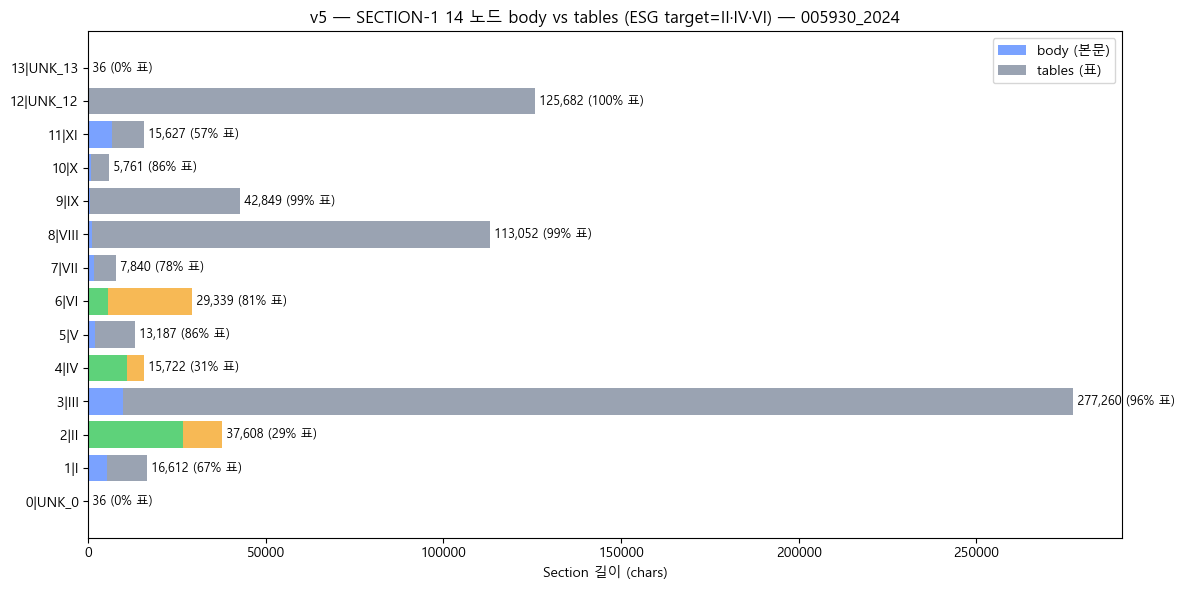

In [9]:
# 시각화 — 14 SECTION-1 body vs tables stacked bar
fig, ax = plt.subplots(figsize=(12, 6))
order = sorted(sections_all.keys(), key=lambda k: sections_all[k]['sec1_index'])
labels = [f"{sections_all[k]['sec1_index']:2d}|{k}" for k in order]
body = [sections_all[k]['body_char_count'] for k in order]
tables = [sections_all[k]['tables_char_count'] for k in order]
colors_body = ['#5ed27a' if k in ESG_TARGET_LABELS else '#7aa2ff' for k in order]
colors_tbl = ['#f7b955' if k in ESG_TARGET_LABELS else '#9aa3b2' for k in order]
ax.barh(labels, body, color=colors_body, label='body (본문)')
ax.barh(labels, tables, left=body, color=colors_tbl, label='tables (표)')
ax.set_xlabel('Section 길이 (chars)')
ax.set_title(f"v5 — SECTION-1 14 노드 body vs tables (ESG target=II·IV·VI) — {PILOT_STOCK}_{PILOT_FISCAL}")
ax.legend()
for i, (b, t) in enumerate(zip(body, tables)):
    if b+t > 0:
        ax.text(b+t, i, f' {b+t:,} ({t/(b+t)*100:.0f}% 표)', va='center', fontsize=9)
plt.tight_layout()
plt.show()


---

## Step 6+ · primary sections.json 저장 (v5 스키마)

dart-fss-text 호환 + 표/본문 분리 추가 필드.


In [10]:
sections_payload = {
    'doc_type': '사업보고서',
    'doc_name_in_xml': PRIMARY_TYPE,
    'fallback_used': FALLBACK,
    'stock_code': PILOT_STOCK,
    'fiscal_year': PILOT_FISCAL,
    'esg_year': PILOT_ESG_YEAR,
    'rcept_no': PILOT_RCEPT,
    'viewer_url': VIEWER_URL,
    'parser_version': 'v5',
    'parsed_at': datetime.now().isoformat(timespec='seconds'),
    'sections': sections_all,
    'esg_target_labels': ESG_TARGET_LABELS,
}
sec_path = DIR_INTERIM / f'{PILOT_STOCK}_{PILOT_FISCAL}_sections.json'
sec_path.write_text(json.dumps(sections_payload, ensure_ascii=False), encoding='utf-8')
print(f"💾 primary sections (v5): {sec_path.name} ({sec_path.stat().st_size/1024:.1f} KB)")

# section_match_v5.csv
match_df = pd.DataFrame([
    {**m, 'stock_code': PILOT_STOCK, 'fiscal_year': PILOT_FISCAL,
     'fallback_used': FALLBACK,
     'timestamp': datetime.now().isoformat(timespec='seconds')}
    for m in match_log
])
match_csv = DIR_LOGS / 'section_match_v5.csv'
match_df.to_csv(match_csv, mode='a', header=not match_csv.exists(), index=False, encoding='utf-8-sig')
print(f"💾 SECTION-1 매칭+분리 로그: {match_csv.name} ({len(match_log)}행)")


💾 primary sections (v5): 005930_2024_sections.json (2339.3 KB)
💾 SECTION-1 매칭+분리 로그: section_match_v5.csv (14행)


---

## Step 7 · ESG passage 추출 — body 기준 (가이드 line 158)

**v5 기본 정책**: ESG 가설 검증의 primary corpus는 **body (본문)**. 표는 02_preprocessing에서 별도 분석 (수치 시계열 등).


In [11]:
def extract_passages_v5(target_sections, seed_df, source='body', min_len=20):
    """source: 'text' (전체) / 'body' (본문) / 'tables' (표) 중 선택."""
    rows = []
    seed_by_dim = seed_df.groupby('dimension')['seed_term'].apply(list).to_dict()
    pattern_by_dim = {dim: re.compile('|'.join(map(re.escape, terms))) for dim, terms in seed_by_dim.items()}

    field = {'text':'section_text', 'body':'section_body', 'tables':'section_tables'}[source]
    for label, sec_dict in tqdm(target_sections.items(), desc=f'passage 추출 ({source})'):
        text = sec_dict.get(field, '')
        if not text: continue
        sentences = re.split(r'(?<=[\.!?])\s+|\n+', text)
        n_pass = 0
        for sent in sentences:
            sent = sent.strip()
            if len(sent) < min_len: continue
            matched_dims, matched_terms = [], []
            for dim, pat in pattern_by_dim.items():
                hits = pat.findall(sent)
                if hits:
                    matched_dims.append(dim)
                    matched_terms.extend(set(hits))
            if matched_dims:
                rows.append({
                    'section': label,
                    'section_code': sec_dict.get('section_code',''),
                    'source': source,
                    'dimensions': '|'.join(sorted(set(matched_dims))),
                    'matched_terms': '|'.join(sorted(set(matched_terms))),
                    'n_matches': len(matched_terms),
                    'sentence': sent,
                })
                n_pass += 1
        if n_pass:
            print(f"   {label}: {n_pass}개")
    return pd.DataFrame(rows)


seeds = pd.read_csv(ROOT / 'data' / 'seed_dictionary.csv')
print(f"🌱 seeds: {len(seeds)}개")

target = {k: sections_all[k] for k in ESG_TARGET_LABELS if k in sections_all}

# body 기준
passages_body = extract_passages_v5(target, seeds, source='body', min_len=20)
print(f"\n📝 passages (body): {len(passages_body)}개")

# tables 기준 비교
passages_tables = extract_passages_v5(target, seeds, source='tables', min_len=20)
print(f"📝 passages (tables): {len(passages_tables)}개")

# 전체 비교 표
print(f"\n📊 source별 passage 수 비교:")
for src, df in [('body', passages_body), ('tables', passages_tables)]:
    if len(df):
        print(f"   {src}: {len(df)}개 / 차원 {df['dimensions'].value_counts().to_dict()}")
    else:
        print(f"   {src}: 0개")


🌱 seeds: 30개


passage 추출 (body):   0%|          | 0/3 [00:00<?, ?it/s]

   II: 24개
   IV: 1개
   VI: 30개

📝 passages (body): 55개


passage 추출 (tables):   0%|          | 0/3 [00:00<?, ?it/s]

   II: 5개
   IV: 4개
   VI: 75개
📝 passages (tables): 84개

📊 source별 passage 수 비교:
   body: 55개 / 차원 {'G': 33, 'E': 15, 'S': 5, 'E|G': 1, 'G|S': 1}
   tables: 84개 / 차원 {'G': 73, 'E': 4, 'S': 3, 'G|S': 2, 'E|G': 2}


In [12]:
# top 10 (body 기준)
if len(passages_body):
    top = passages_body.sort_values('n_matches', ascending=False).head(10)
    pd.set_option('display.max_colwidth', 200)
    display(top[['section','section_code','dimensions','matched_terms','sentence']])


,section,section_code,dimensions,matched_terms,sentence
42,VI,060000,G,감사위원회|독립성|사외이사|이사회|주주,"감사위원회 위원의 독립성 당사는 관련 법령 및 정관에 따라 위원회의 구성, 운영 및 권한ㆍ책임 등을 감사위원회 규정에 정의하여 감사업무를 수행하고 있습니다.감사위원회 위원 전원은 이사회 및 사외이사 후보추천위원회의 추천을 받고 주주총회의 결의를 통해 선임한 재무전문가(김한조 위원)와 미국 변호사 자격 소지자(유명희 위원), 타 상장법인의 감사위원(조..."
33,VI,060000,G,독립성|사외이사|이사회|주주,"이사의 독립성 (1) 이사의 선임 이사는 주주총회에서 선임하며, 주주총회에서 선임할 이사 후보 중 사내이사는 이사회에서 추천하고 사외이사 후보는 사외이사후보추천위원회에서 추천하여, 이사회가 이를 검토해서 주주총회의 회의목적 사항으로 확정합니다.이사 선임에 있어서는 관련 법령과 정관에 정한 요건의 충족 여부를 확인하고 있습니다."
5,II,020000,E,에너지|온실가스|탄소,특히 정부의 저탄소 녹색성장 정책에 부응하여 관련 법규에서요구하는 사업장에서 발생하는 온실가스 배출량과 에너지 사용량을 정부에 신고하고지속가능보고서 등을 통하여 이해관계자에게 관련 정보를 투명하게 제공하고 있습니다.
28,VI,060000,G,감사위원회|사외이사|이사회,"이사회내 위원회로는 경영위원회, 감사위원회, 사외이사후보추천위원회, 내부거래위원회, 보상위원회, 지속가능경영위원회가 설치되어 운영 중입니다."
34,VI,060000,E|G,사외이사|에너지|주주,"사내이사는 상시 관리하는 후보군 중 전문성과 리더십 면에서 가장 적합한 인물을 후보로 선정하고, 사외이사는 전자 산업에 대한 이해와 재무, 법률, IT( 로봇, AI), ESG, 금융, 투자, 환경, 에너지, 국제통상, Risk 관리 등 전문 분야에 대한 경력이 풍부하고, 회사 및 최대주주와 이해관계가 없어 독립적인 지위에서 이사와 회사의 경영을 감..."
13,II,020000,E,에너지|온실가스|탄소,기타 사업장환경관리법:「화학물질관리법」 「화학물질의 등록 및 평가 등에 관한 법률」 「악취방지법」「토양환경보전법」등 (온실가스 배출량 및 에너지 사용량 관리) 당사는 국내에서「기후위기 대응을 위한 탄소중립ㆍ녹색성장기...
43,VI,060000,G,감사위원회|독립성|주주,"동 위원회 위원은 당사, 당사의 최대주주 또는 주요주주와 감사위원회 활동의 독립성을 저해할 어떠한 관계도 없습니다."
51,VI,060000,G,의결권|이사회|주주,"당사 이사회는 2020년 1월 30일 의결권 행사에 있어 주주의 편의를 제고하기 위하여「상법」제368조의4(전자적 방법에 의한 의결권의 행사)에 따라 전자투표제를 채택하였으며, 당사는 2020년 3월 18일에 개최한 제51기 정기주주총회부터 전자투표제를 시행하고 있습니다.당사는 주주총회 소집공고 시 전자적 방법으로 의결권을 행사할 수 있다는 내용을 ..."
27,VI,060000,G,독립성|사외이사|이사회,"이사회는 이사회의 독립성과 투명성 제고를 위하여 이사회 의장을 대표이사와 분리하여, 김한조 사외이사를 이사 간 의견 조율과 이사회 활동을 총괄하는 적임자로 판단해 의장으로 선임하였습니다."
20,II,020000,E,재활용|폐기물,대표적으로 플라스틱 폐기물 중 하나인 폐어망을 재활용해 만든 소재를 Galaxy S22 시리즈 이후 많은 과제에 적용하고 있습니다.


---

## Step 8 · viewer 정합성 검증 (가이드 line 67, 94)


In [13]:
print(f"🔗 viewer URL: {VIEWER_URL}\n")
print(f"👉 v5 — body 기준 passage 5건 sample (G 차원 비중 안정성 확인용):\n")
print("=" * 70)

if len(passages_body):
    sample = passages_body.sample(min(5, len(passages_body)), random_state=42)
    for i, (idx, row) in enumerate(sample.iterrows(), 1):
        print(f"\n[{i}] {row['section']} (sec_code={row['section_code']}, source={row['source']}) · {row['dimensions']} · {row['matched_terms']}")
        print(f"    {row['sentence'][:200]}...")
print("\n" + "=" * 70)
print("판정 기준: ✅ ≥ 4/5 → Phase 2A 진입 / ⚠️ 3/5 / 🔴 ≤ 2/5 → v6")


🔗 viewer URL: https://dart.fss.or.kr/dsaf001/main.do?rcpNo=20250311001085

👉 v5 — body 기준 passage 5건 sample (G 차원 비중 안정성 확인용):


[1] VI (sec_code=060000, source=body) · G · 주주
    경영일반에 관한 사항 1) 회사의 연간 또는 중장기 경영방침 및 전략 2) 주요 경영전략 3) 사업계획ㆍ사업구조 조정 추진 4) 해외 지점ㆍ법인의 설치, 이전 및 철수 5) 해외업체와의 전략적 제휴 등 협력추진 6) 국내외 주요 자회사 매입 또는 매각(자기자본 0.1% 이상인 경우에 한함) 7) 기타 주요 경영현황 8) 지점, 사업장의 설치 및 이전, 폐지...

[2] II (sec_code=020000, source=body) · E · 에너지|온실가스|탄소
    특히 정부의 저탄소 녹색성장 정책에 부응하여 관련 법규에서요구하는 사업장에서 발생하는 온실가스 배출량과 에너지 사용량을 정부에 신고하고지속가능보고서 등을 통하여 이해관계자에게 관련 정보를 투명하게 제공하고 있습니다....

[3] VI (sec_code=060000, source=body) · G · 이사회|주주
    기타 이사회에서 위임한 사항 또는 이사회의 권한에 속하는 사항 중 이사회 규정에 따라 이사회에 부의할 사항으로 명시된 사항과 다른 위원회에 위임한 사항을 제외한 일체의 사항 (내부거래위원회) - 설치목적: 공정거래 자율준수 체제 구축을 통해 회사 경영의 투명성을 제고하기 위함 - 권한사항   ㆍ내부거래 보고 청취권: 계열사와의 내부거래 현황에 대해 보고받을...

[4] II (sec_code=020000, source=body) · E · 에너지|온실가스|탄소
    기타 사업장환경관리법:「화학물질관리법」                                       「화학물질의 등록 및 평가 등에 관한 법률」                          

---

## Step 9 · collection_log v5 + 시각화

v4 컬럼 + Fix #12·#13 신규 컬럼 (`fallback_used`, `sec_*_body_len`, `sec_*_tables_len`, `n_tables`).


In [14]:
EXPECTED_LOG_COLUMNS_V5 = [
    'stock_code','fiscal_year','esg_year','corp_code','rcept_no',
    'fallback_used','status','reason','n_passages_body','n_passages_tables',
    'sec_II_code','sec_II_text','sec_II_body','sec_II_tables','sec_II_n_tbl',
    'sec_IV_code','sec_IV_text','sec_IV_body','sec_IV_tables','sec_IV_n_tbl',
    'sec_VI_code','sec_VI_text','sec_VI_body','sec_VI_tables','sec_VI_n_tbl',
    'n_sec1_total','viewer_url','parser_version','timestamp',
]


def append_log_v5(log_path, row):
    if log_path.exists():
        try:
            existing = pd.read_csv(log_path, nrows=0)
            if list(existing.columns) != EXPECTED_LOG_COLUMNS_V5:
                stamp = datetime.now().strftime('%Y%m%d_%H%M%S')
                bak = log_path.with_suffix(f'.csv.bak_{stamp}')
                log_path.rename(bak)
                print(f"⚠️ log 컬럼 mismatch → 백업: {bak.name}")
        except Exception as e:
            stamp = datetime.now().strftime('%Y%m%d_%H%M%S')
            bak = log_path.with_suffix(f'.csv.bak_{stamp}')
            log_path.rename(bak)
    df_row = pd.DataFrame([row], columns=EXPECTED_LOG_COLUMNS_V5)
    df_row.to_csv(log_path, mode='a', header=not log_path.exists(), index=False, encoding='utf-8-sig')
    return pd.read_csv(log_path)


def _get(label, field):
    return sections_all.get(label, {}).get(field, 0)

n_pass_body = len(passages_body)
n_pass_tables = len(passages_tables)

dim_b = passages_body['dimensions'].apply(lambda x: x.split('|')).explode().value_counts().to_dict() if n_pass_body else {}
e_n, s_n, g_n = dim_b.get('E',0), dim_b.get('S',0), dim_b.get('G',0)

if _get('II','text_char_count') == 0 and _get('IV','text_char_count') == 0 and _get('VI','text_char_count') == 0:
    status, reason = 'FAIL_SECTION_NOT_FOUND', '모두 0자'
elif n_pass_body == 0:
    status, reason = 'FAIL_PASSAGE', 'body passage 0건'
elif min(e_n, s_n, g_n) < 5:
    status, reason = 'WARN_DIM_IMBALANCE', f'body E={e_n}, S={s_n}, G={g_n}'
elif FALLBACK != 'PRIMARY_BIZ':
    status, reason = f'WARN_FALLBACK_{FALLBACK}', f'사업보고서 없음, {FALLBACK} 사용 (가이드 line 172 준수)'
else:
    status, reason = 'SUCCESS', ''

log_row = {
    'stock_code': PILOT_STOCK, 'fiscal_year': PILOT_FISCAL, 'esg_year': PILOT_ESG_YEAR,
    'corp_code': PILOT_CORP, 'rcept_no': PILOT_RCEPT,
    'fallback_used': FALLBACK, 'status': status, 'reason': reason,
    'n_passages_body': n_pass_body, 'n_passages_tables': n_pass_tables,
    'sec_II_code': _get('II','section_code'),
    'sec_II_text': _get('II','text_char_count'),
    'sec_II_body': _get('II','body_char_count'),
    'sec_II_tables': _get('II','tables_char_count'),
    'sec_II_n_tbl': _get('II','n_tables'),
    'sec_IV_code': _get('IV','section_code'),
    'sec_IV_text': _get('IV','text_char_count'),
    'sec_IV_body': _get('IV','body_char_count'),
    'sec_IV_tables': _get('IV','tables_char_count'),
    'sec_IV_n_tbl': _get('IV','n_tables'),
    'sec_VI_code': _get('VI','section_code'),
    'sec_VI_text': _get('VI','text_char_count'),
    'sec_VI_body': _get('VI','body_char_count'),
    'sec_VI_tables': _get('VI','tables_char_count'),
    'sec_VI_n_tbl': _get('VI','n_tables'),
    'n_sec1_total': len(sections_all),
    'viewer_url': VIEWER_URL, 'parser_version': 'v5',
    'timestamp': datetime.now().isoformat(timespec='seconds'),
}

log_df = append_log_v5(DIR_LOGS / 'collection_log.csv', log_row)
print(f"\n✅ collection_log v5: status={status}, fallback={FALLBACK}")
print(f"   누적: {len(log_df)}행")
log_df.tail(3)



✅ collection_log v5: status=SUCCESS, fallback=PRIMARY_BIZ
   누적: 2행


,stock_code,fiscal_year,esg_year,corp_code,rcept_no,fallback_used,status,reason,n_passages_body,n_passages_tables,...,sec_IV_n_tbl,sec_VI_code,sec_VI_text,sec_VI_body,sec_VI_tables,sec_VI_n_tbl,n_sec1_total,viewer_url,parser_version,timestamp
0,5930,2024,2025,126380,20250311001085,PRIMARY_BIZ,SUCCESS,NaN,55,84,...,28,60000,29728,5653,23686,64,14,https://dart.fss.or.kr/dsaf001/main.do?rcpNo=20250311001085,v5,2026-05-16T19:39:44
1,5930,2024,2025,126380,20250311001085,PRIMARY_BIZ,SUCCESS,NaN,55,84,...,28,60000,29728,5653,23686,64,14,https://dart.fss.or.kr/dsaf001/main.do?rcpNo=20250311001085,v5,2026-05-16T21:50:04


💾 correction_log: 1행


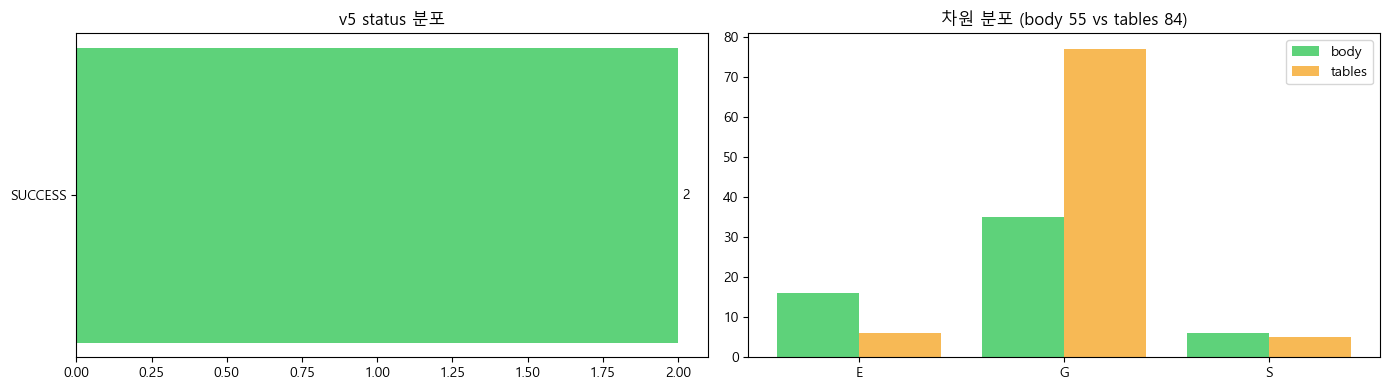


v5 결과 요약 (Fix #12 표/본문 분리):
   body passage : 55건 (E=16, S=6, G=35)
   tables passage: 84건
   fallback_used: PRIMARY_BIZ


In [15]:
# correction_log
correction_rows = [{
    'stock_code': PILOT_STOCK, 'fiscal_year': PILOT_FISCAL,
    'rcept_no': c['rcept_no'], 'rcept_dt': c['rcept_dt'], 'report_nm': c['report_nm'],
    'fallback_used': c['fallback_used'],
    'is_selected': c['rcept_no']==PILOT_RCEPT,
    'timestamp': datetime.now().isoformat(timespec='seconds'),
} for c in result_step4['all_candidates']]
if correction_rows:
    cdf = pd.DataFrame(correction_rows)
    cpath = DIR_LOGS / 'correction_log.csv'
    cdf.to_csv(cpath, mode='a', header=not cpath.exists(), index=False, encoding='utf-8-sig')
    print(f"💾 correction_log: {len(correction_rows)}행")

# 시각화 — body vs tables passage 비교
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
status_counts = log_df['status'].value_counts()
status_colors = {'SUCCESS': '#5ed27a', 'WARN_DIM_IMBALANCE': '#f7b955'}
colors = [status_colors.get(s, '#ef6f6c') for s in status_counts.index]
axes[0].barh(status_counts.index, status_counts.values, color=colors)
axes[0].set_title('v5 status 분포')
for i, v in enumerate(status_counts.values):
    axes[0].text(v, i, f' {v}', va='center')

# body vs tables passage 차원 분포
if n_pass_body or n_pass_tables:
    body_dim = passages_body['dimensions'].apply(lambda x: x.split('|')).explode().value_counts() if n_pass_body else pd.Series()
    tbl_dim = passages_tables['dimensions'].apply(lambda x: x.split('|')).explode().value_counts() if n_pass_tables else pd.Series()
    all_dims = sorted(set(body_dim.index) | set(tbl_dim.index))
    x = range(len(all_dims))
    w = 0.4
    axes[1].bar([i-w/2 for i in x], [body_dim.get(d,0) for d in all_dims], width=w, label='body', color='#5ed27a')
    axes[1].bar([i+w/2 for i in x], [tbl_dim.get(d,0) for d in all_dims], width=w, label='tables', color='#f7b955')
    axes[1].set_xticks(list(x)); axes[1].set_xticklabels(all_dims)
    axes[1].set_title(f'차원 분포 (body {n_pass_body} vs tables {n_pass_tables})')
    axes[1].legend()
plt.tight_layout(); plt.show()

print(f"\nv5 결과 요약 (Fix #12 표/본문 분리):")
print(f"   body passage : {n_pass_body}건 (E={e_n}, S={s_n}, G={g_n})")
print(f"   tables passage: {n_pass_tables}건")
print(f"   fallback_used: {FALLBACK}")


---

## Step 10 · 위반금지 8항목 self-check (가이드 line 145)


In [16]:
checks = [
    ('1. 실패 행 가짜 0 ❌', 'line 172, 286',
     '✅' if (status == 'SUCCESS' or status.startswith('WARN_FALLBACK_') or (status.startswith('FAIL_') and reason)) else '❌',
     f'status={status}, reason={reason!r}'),
    ('2. viewer 우회 ❌', 'line 67, 94', '✅', 'document.xml 사용'),
    ('3. MCP/추출 그대로 신뢰 ❌', 'line 94', '⏳ 사용자 검증', 'Step 8 viewer 5 sample'),
    ('4. API key 출력 ❌', 'line 216-222', '✅', 'mask_key + KEY_CANDIDATES'),
    ('5. raw 미보존 ❌', 'line 155', '✅' if result_step5['zip_path'].exists() else '❌', str(result_step5['zip_path'])),
    ('6. 진단 부재 ❌', 'line 143-146', '✅', 'SECTION-1 14 + body/tables 분리 출력'),
    ('7. silent 오매칭 ❌', 'line 35', '✅', 'stock_code 기준'),
    ('8. 평가 기준 부재 ❌', 'line 145', '✅', 'viewer 5/5 + 본 표 + body/tables 비교'),
]
print("📋 v5 self-check\n" + "=" * 80)
check_df = pd.DataFrame(checks, columns=['항목', '가이드 라인', '결과', '근거'])
display(check_df)

print(f"\n📌 v5 신규 fix 검증:")
print(f"   Fix #12 표/본문 분리: ✅ 3가지 모두 저장 (text/body/tables)")
print(f"   Fix #13 fallback: ✅ fallback_used={FALLBACK}")
print(f"\n📌 가이드 line 18 (II/IV/VI):")
for label in ESG_TARGET_LABELS:
    if label in sections_all:
        s = sections_all[label]
        print(f"   {label} ({s['section_code']}): text={s['text_char_count']:,}/body={s['body_char_count']:,}/tables={s['tables_char_count']:,} ({s['table_ratio']*100:.0f}% 표)")


📋 v5 self-check


,항목,가이드 라인,결과,근거
0,1. 실패 행 가짜 0 ❌,"line 172, 286",✅,"status=SUCCESS, reason=''"
1,2. viewer 우회 ❌,"line 67, 94",✅,document.xml 사용
2,3. MCP/추출 그대로 신뢰 ❌,line 94,⏳ 사용자 검증,Step 8 viewer 5 sample
3,4. API key 출력 ❌,line 216-222,✅,mask_key + KEY_CANDIDATES
4,5. raw 미보존 ❌,line 155,✅,c:\Users\kik32\workspace\unstructured-data-processing-final-project\data\raw\005930_2024_disclosure.zip
5,6. 진단 부재 ❌,line 143-146,✅,SECTION-1 14 + body/tables 분리 출력
6,7. silent 오매칭 ❌,line 35,✅,stock_code 기준
7,8. 평가 기준 부재 ❌,line 145,✅,viewer 5/5 + 본 표 + body/tables 비교



📌 v5 신규 fix 검증:
   Fix #12 표/본문 분리: ✅ 3가지 모두 저장 (text/body/tables)
   Fix #13 fallback: ✅ fallback_used=PRIMARY_BIZ

📌 가이드 line 18 (II/IV/VI):
   II (020000): text=37,632/body=26,663/tables=10,945 (29% 표)
   IV (040000): text=15,726/body=10,919/tables=4,803 (31% 표)
   VI (060000): text=29,728/body=5,653/tables=23,686 (80% 표)


---

## Step 11 · v1→v2→v3→v4→v5 학습 로그

| 버전 | 핵심 결과 | 학습 |
|---|---|---|
| v1 | 섹션 0건 | zip 첫 파일만 → 연결감사보고서 |
| v2 | viewer 0/5 | concat → 감사보고서 노이즈 |
| v3 | II/IV/VI 0자 | 정규식이 목차·본문 구분 실패 |
| v4 | viewer 4/5 ✅ | dart-fss-text 패턴 (SECTION-1 + section_code) |
| **v5** | **표/본문 분리 + fallback** | VI 81% 표 발견 → body/tables 분리 보존 |

다음 노트북 인계 (02_preprocessing):
- `data/interim/<stock>_<year>_sections.json` — **section_text + section_body + section_tables 3가지**
- `logs/collection_log.csv` — body·tables 분리 통계 컬럼
- `logs/correction_log.csv` — fallback 이력 포함
- `logs/section_match_v5.csv` — 회사별 표 비중 분포 (Phase 2A 모니터링)

### v5 분기
- viewer ≥ 4/5 body 기준 + E·S·G 각 ≥ 5 → **Phase 2A 50건 batch 진입**
- viewer 3/5 → fuzzy matching (Fix #9) 활성화
- viewer ≤ 2/5 → v6
